In [62]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, losses, callbacks, models, optimizers

In [63]:
def evaluate_model(model, X, y_true, label_encoder, title="Model Performance"):
    print(f"\nGenerating predictions for {title}...")
    # Wrap X_test in a tensor to avoid the 'str' dtype issue in predict
    X_tensor = tf.convert_to_tensor(X.astype(str).values, dtype=tf.string)
    y_pred_probs = model.predict(X_tensor)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\n--- {title}: Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'go-', label='Validation Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro-', label='Training Loss')
    plt.plot(epochs, val_loss, 'yo-', label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

In [64]:
import os
import json
from datetime import datetime

def save_complete_run(model, history, X_test, y_test, label_encoder, base_dir="model_runs"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(base_dir, f"run_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)

    # Save Model
    model.save(os.path.join(run_dir, "model.keras"))

    # Save Training History
    with open(os.path.join(run_dir, "history.json"), "w") as f:
        json.dump(history.history, f, indent=4)

    # Generate and Save Evaluation Metrics
    print(f"\nGenerating predictions for run {timestamp}...")
    X_tensor = tf.convert_to_tensor(X_test.astype(str).values, dtype=tf.string)
    y_pred_probs = model.predict(X_tensor)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Save Classification Report
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
    with open(os.path.join(run_dir, "classification_report.json"), "w") as f:
        json.dump(report, f, indent=4)

    print(f"\n--- Classification Report for run {timestamp} ---")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Save Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: Run {timestamp}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"))
    plt.close() # Close the plot to prevent it from displaying unnecessarily

    print(f"Model and evaluation results saved to: {run_dir}")

In [65]:
DATA_PATH = 'CombinedData.csv'

if not os.path.exists(DATA_PATH):
    print(f"Error: Please upload {DATA_PATH} to the Colab files tab.")
else:
    df = pd.read_csv(DATA_PATH)
    df = df.dropna(subset=['statement', 'status']).copy()

    # Encode Labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df['status'])
    num_classes = len(label_encoder.classes_)

    X_train, X_test, y_train, y_test = train_test_split(
        df['statement'].astype(str), y_encoded, test_size=0.3,
        random_state=42, stratify=y_encoded
    )

    print(f"Data ready. Classes: {label_encoder.classes_}")

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")

Data ready. Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
X_train shape: (36876,)
y_train shape: (36876,)
X_test shape: (15805,)
y_test shape: (15805,)


In [66]:
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

y_train_one_hot shape: (36876, 7)
y_test_one_hot shape: (15805, 7)


In [ ]:
# --- Configuration ---
MAX_VOCAB = 15000 
MAX_SEQUENCE = 256 
num_classes = 7

vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_VOCAB,
    output_sequence_length=MAX_SEQUENCE,
    name="vectorizer" # Assign a name
)
vectorize_layer.adapt(X_train.values) 

input_text = layers.Input(shape=(1,), dtype=tf.string, name="input_text")

vectorized_text = vectorize_layer(input_text) 

# Embedding & Initial Noise Reduction
embedding = layers.Embedding(MAX_VOCAB, 128, name="embedding", mask_zero=True)(vectorized_text)
spatial_dropout = layers.SpatialDropout1D(0.2, name="spatial_dropout")(embedding)

strip_mask = layers.Lambda(lambda x: x, mask=None, name="strip_mask")(spatial_dropout)

# --- Path 1: Recurrent (The "Feeling" over time) ---
bidirectional_3 = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True),
    name="bidirectional_3"
)(spatial_dropout)
lstm_avg = layers.GlobalAveragePooling1D(name="lstm_avg")(bidirectional_3)
lstm_max = layers.GlobalMaxPooling1D(name="lstm_max")(bidirectional_3)
lstm_pool_merge = layers.Concatenate(name="lstm_pool_merge")([lstm_avg, lstm_max])

# --- Path 2: Convolutional (Keyword/phrase spotting) ---
conv1d_14 = layers.Conv1D(64, 3, padding='same', activation='relu', name="conv1d_14")(strip_mask)
conv1d_15 = layers.Conv1D(64, 5, padding='same', activation='relu', name="conv1d_15")(strip_mask)
cnn_merge = layers.Concatenate(name="cnn_merge")([conv1d_14, conv1d_15])
cnn_max = layers.GlobalMaxPooling1D(name="cnn_max")(cnn_merge)

# --- Path 3: Attention (Contextual Weighting) ---
mha = layers.MultiHeadAttention(num_heads=4, key_dim=32, name="multi_head_attention")(strip_mask, strip_mask)
attn_max = layers.GlobalMaxPooling1D(name="attn_max")(mha)

# --- Merge and Residual Dense Block ---
global_merge = layers.Concatenate(name="global_merge")([lstm_pool_merge, cnn_max, attn_max])

# Dense block with residual connection to help with vanishing gradients
dense_base = layers.Dense(256, activation='relu', name="dense_base")(global_merge)
dense_residual = layers.Dense(256, activation='relu', name="dense_residual")(dense_base)
residual_add = layers.Add(name="residual_add")([dense_base, dense_residual])

final_dropout = layers.Dropout(0.3, name="final_dropout")(residual_add)
classifier = layers.Dense(num_classes, activation='softmax', name="classifier")(final_dropout)

# --- Compilation with Focal Loss ---
model = models.Model(inputs=input_text, outputs=classifier, name="reconstructed_hybrid")

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    # Focal Loss is a type of loss function that focuses training on hard examples, which is crucial for imbalanced datasets like this one
    loss=losses.CategoricalFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'strip_mask' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'lstm_max' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "reconstructed_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vectorizer          │ (None, 256)       │          0 │ input_text[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  1,920,000 │ vectorizer[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 256, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_33        │ (None, 256)       │          0 │ vectorizer[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ strip_mask (Lambda) │ (None, 256, 128)  │          0 │ spatial_dropout[… │
│                     │                   │            │ not_equal_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 256, 128)  │     98,816 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │ not_equal_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 256, 64)   │     24,640 │ strip_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 256, 64)   │     41,024 │ strip_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_avg            │ (None, 128)       │          0 │ bidirectional_3[… │
│ (GlobalAveragePool… │                   │            │ not_equal_33[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_max            │ (None, 128)       │          0 │ bidirectional_3[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_merge           │ (None, 256, 128)  │          0 │ conv1d_14[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ strip_mask[0][0], │
│ (MultiHeadAttentio… │                   │            │ strip_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_pool_merge     │ (None, 256)       │          0 │ lstm_avg[0][0],   │
│ (Concatenate)       │                   │            │ lstm_max[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_max             │ (None, 128)       │          0 │ cnn_merge[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_max            │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_merge        │ (None, 512)       │          0 │ lstm_pool_merge[… │
│ (Concatenate)       │                   │            │ cnn_max[0][0],    │
│                     │                   │            │ attn_max[0][0]  

 Total params: 2,349,447 (8.96 MB)

 Trainable params: 2,349,447 (8.96 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

class_weights[2] = 1.0
class_weights[6] = 1.75

print("Calculated Class Weights:")
for i, weight in class_weights.items():
    print(f"  Class {label_encoder.classes_[i]}: {weight:.2f}")


Calculated Class Weights:
  Class Anxiety: 1.96
  Class Bipolar: 2.71
  Class Depression: 1.00
  Class Normal: 0.46
  Class Personality disorder: 6.99
  Class Stress: 2.91
  Class Suicidal: 1.75


In [89]:
monitor = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train.values,
    y_train_one_hot,
    batch_size=128,
    validation_split=0.3,
    epochs=10,
    callbacks=[monitor, lr_schedule],
    class_weight=class_weights
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_14' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_15' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'attn_max' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.3492 - loss: 0.4158 - val_accuracy: 0.5198 - val_loss: 0.1959 - learning_rate: 1.0000e-04
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.5320 - loss: 0.2865 - val_accuracy: 0.5708 - val_loss: 0.1419 - learning_rate: 1.0000e-04
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.5786 - loss: 0.2228 - val_accuracy: 0.6040 - val_loss: 0.1278 - learning_rate: 1.0000e-04
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.6245 - loss: 0.1899 - val_accuracy: 0.6618 - val_loss: 0.1155 - learning_rate: 1.0000e-04
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.6704 - loss: 0.1586 - val_accuracy: 0.6819 - val_loss: 0.1016 - learning_rate: 1.0000e-04
Epoch 6/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.7093 - loss: 0.1271 - val_accuracy: 0.6910 - val_loss: 0.0948 - learning_rate: 1.0000e-04
Epoch 7/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accurac

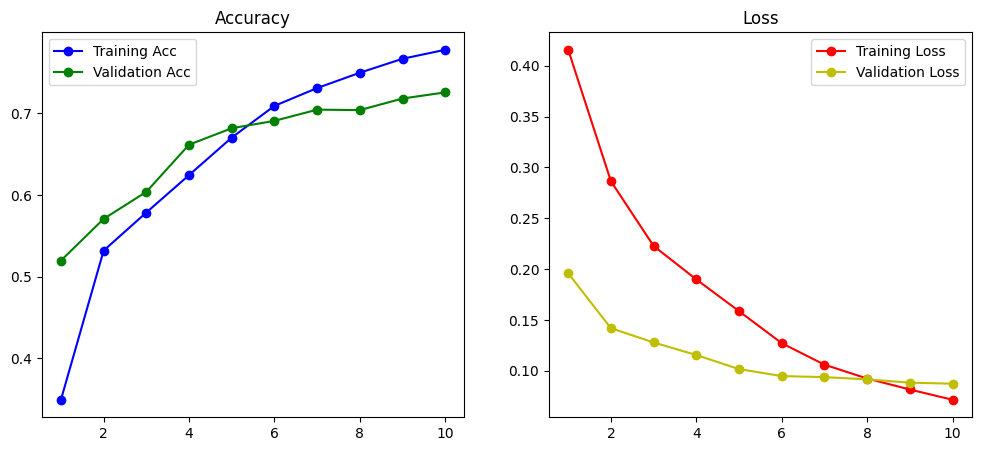


Generating predictions for Final Test Results...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'strip_mask' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_14' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d_15' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ke

494/494 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step

--- Final Test Results: Classification Report ---
                      precision    recall  f1-score   support

             Anxiety       0.76      0.77      0.77      1152
             Bipolar       0.76      0.75      0.75       833
          Depression       0.78      0.48      0.60      4622
              Normal       0.92      0.89      0.90      4903
Personality disorder       0.42      0.63      0.50       323
              Stress       0.46      0.51      0.49       776
            Suicidal       0.55      0.85      0.67      3196

            accuracy                           0.72     15805
           macro avg       0.67      0.70      0.67     15805
        weighted avg       0.75      0.72      0.72     15805



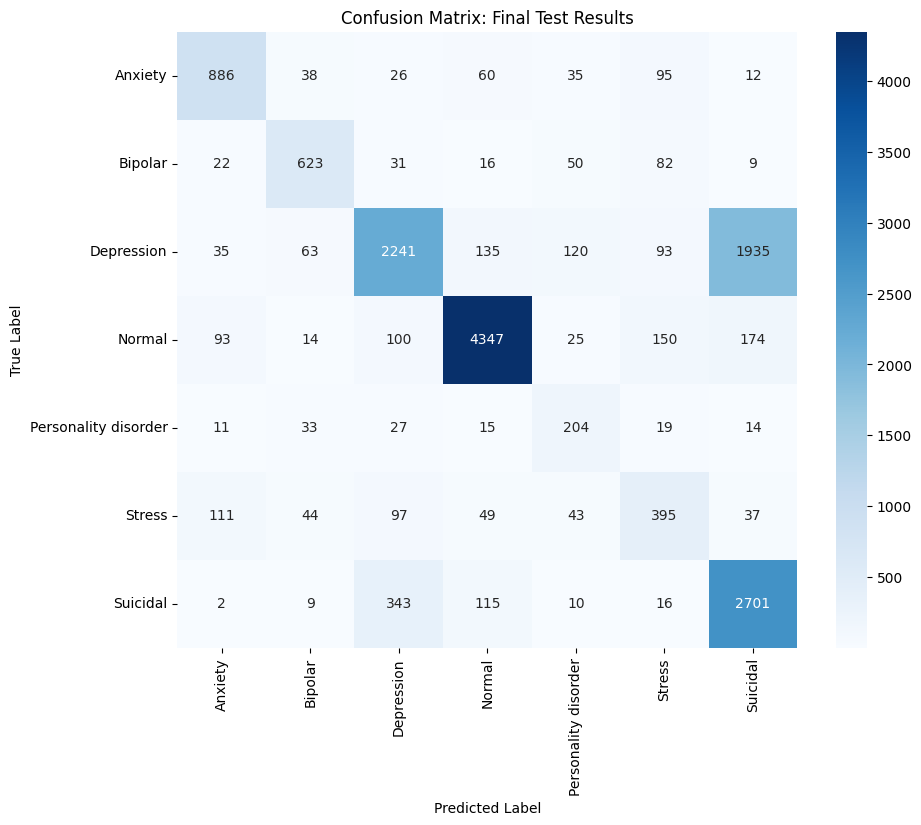


Generating predictions for run 20260423_001654...
494/494 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step

--- Classification Report for run 20260423_001654 ---
                      precision    recall  f1-score   support

             Anxiety       0.76      0.77      0.77      1152
             Bipolar       0.76      0.75      0.75       833
          Depression       0.78      0.48      0.60      4622
              Normal       0.92      0.89      0.90      4903
Personality disorder       0.42      0.63      0.50       323
              Stress       0.46      0.51      0.49       776
            Suicidal       0.55      0.85      0.67      3196

            accuracy                           0.72     15805
           macro avg       0.67      0.70      0.67     15805
        weighted avg       0.75      0.72      0.72     15805

Model and evaluation results saved to: model_runs/run_20260423_001654


In [90]:
plot_history(history)
evaluate_model(model, X_test, y_test, label_encoder, title="Final Test Results")
save_complete_run(model, history, X_test, y_test, label_encoder)

In [ ]:
def predict_statement(statement, model_to_use, label_encoder):
    # Ensure the statement is a string and wrap it in a list for the model input
    statement_tensor = tf.convert_to_tensor([statement], dtype=tf.string)

    # Get raw predictions (probabilities for each class)
    predictions = model_to_use.predict(statement_tensor)[0]

    print(f"Statement: '{statement}'")
    # Order of classes ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress' 'Suicidal']
    print(f"Anxiety Confidence: {predictions[1]*100:.4f}")
    print(f"Bipolar Confidence: {predictions[2]*100:.4f}")
    print(f"Depression Confidence: {predictions[0]*100:.4f}")
    print(f"Normal Confidence: {predictions[3]*100:.4f}")
    print(f"Personality Disorder Confidence: {predictions[4]*100:.4f}")
    print(f"Stress Confidence: {predictions[5]*100:.4f}")
    print(f"Suicidal Confidence: {predictions[6]*100:.4f}")

# Example usage:
user_statement = "i've been feeling so hopeless lately and the world would be better without me but i have no plans to actually do anything about it"
predict_statement(user_statement, model, label_encoder)

user_statement = "work has been completely overwhelming and i can feel the tension in my shoulders and neck all day. i just can't relax even when i get home"
predict_statement(user_statement, model, label_encoder)

user_statement = "yesterday i felt like i was on top of the world and could do anything but today i woke up and i can't even move my life is falling apart"
predict_statement(user_statement, model, label_encoder)

user_statement = "i am literally dying laughing at this video it is so funny i can't breathe"
predict_statement(user_statement, model, label_encoder)

user_statement = "i have this constant feeling that something terrible is about to happen and i can't stop my heart from racing even though nothing is wrong"
predict_statement(user_statement, model, label_encoder)

predict_statement("i'm so done with life", model, label_encoder)

predict_statement("too many deadlines i am going to snap", model, label_encoder)

predict_statement("it is a beautiful day for a walk", model, label_encoder)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Statement: 'i've been feeling so hopeless lately and the world would be better without me but i have no plans to actually do anything about it'
Anxiety Confidence: 0.2910
Bipolar Confidence: 35.3385
Depression Confidence: 0.3941
Normal Confidence: 4.2176
Personality Disorder Confidence: 2.0105
Stress Confidence: 1.1473
Suicidal Confidence: 56.6011
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Statement: 'work has been completely overwhelming and i can feel the tension in my shoulders and neck all day. i just can't relax even when i get home'
Anxiety Confidence: 3.8305
Bipolar Confidence: 19.7336
Depression Confidence: 6.5894
Normal Confidence: 21.6900
Personality Disorder Confidence: 5.6517
Stress Confidence: 31.2415
Suicidal Confidence: 11.2633
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Statement: 'yesterday i felt like i was on top of the world and could do anything but today i woke up and i can't even move my life is falling apart'
Anxiety Confidence: 0.6701